In [1]:
import torch
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from xFNO import FNO, xFNO
import pickle
from special_loss_functions import *

random.seed(100)
device = "cpu"

In [2]:
def train(dataloader, model, loss_fn, optimizer):
    num_batches = len(dataloader)
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)     
        pred = model(X)
        loss = loss_fn(pred, y)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss /= num_batches
    return loss

def test(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
    loss /= num_batches
    return loss

In [3]:
# Load PDE solution
with open('data/KuramotoSivashinsky/KS_N32.pkl', 'rb') as file:
    data = pickle.load(file)
data = torch.tensor(data)
Nx = data.size()[1]
print(data.size())

torch.Size([2001, 32])


In [4]:
# Make datasets, dataloaders
history = 1
shuffle_flag=True # shuffling helps a lot
dt = 1 # increasing this erodes prediction accuracy
training_size = 1024
data_truncated = data[:history*(data.size()[0]//history), :]

features = data_truncated[:-dt, :].to(torch.float32)
features = torch.reshape(features, (features.size()[0], features.size()[1], 1))

labels = data_truncated[dt:, :].to(torch.float32)
labels = torch.reshape(labels, (labels.size()[0], labels.size()[1], 1))

# datasets
if shuffle_flag: 
    idx = torch.randperm(training_size)
else:
    idx = torch.arange(training_size)
training_dataset = TensorDataset(features[idx, :, :], labels[idx, :])
testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :])

# dataloaders
batch_size = 64
training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=False)
testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# initialize operator
Nf = 1
Nlifted = 32 #8 #8 #4
Nk_truncated = 8
depth = 2 # compare with depth 0

neuralop = xFNO((Nx, Nf), Nlifted, (Nk_truncated,), depth).to(device) # lifted dim: not too small, not too large # fourier layer: not too deep
loss_fn = H1Loss(reduction='mean')
loss_fn = H1Loss_With_MassConservation(reduction='mean', lam=1)
loss_fn_test = torch.nn.MSELoss(reduction='mean')
total_params = sum(p.numel() for p in neuralop.parameters())
print(total_params)

rate = 2E-04
optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)
testing_loss = []
training_loss = []

37089


Train Loss: 0.13579, Test Loss: 1.55210
Train Loss: 0.01293, Test Loss: 0.13382
Train Loss: 0.00554, Test Loss: 0.05608
Train Loss: 0.00366, Test Loss: 0.03901
Train Loss: 0.00285, Test Loss: 0.03166


[]

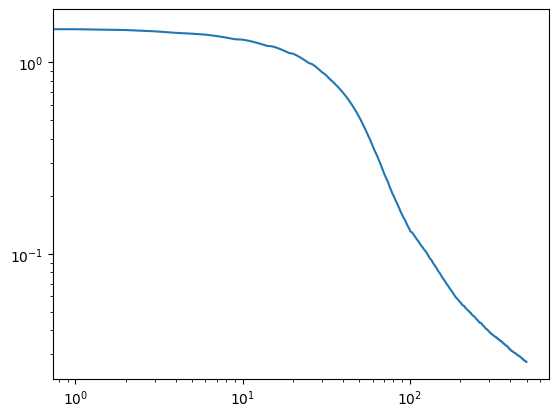

In [9]:
# train
epochs = 500
for i in range(epochs):
    training_loss += [train(training_dataloader, neuralop, loss_fn, optimizer_neuralop)]
    testing_loss += [test(testing_dataloader, neuralop, loss_fn_test)]
    if i%100==0:
        print(f"Train Loss: {(training_loss[-1]):>0.5f}, Test Loss: {(testing_loss[-1]):>0.5f}")
        rate *= 0.7 
        optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)
    if np.isnan(testing_loss[-1]): 
        print('nan!')
        break
plt.figure()
plt.plot(testing_loss)
plt.loglog()

mass of estimate: -0.002750307321548462, mass of solution: 1.8311741012411176e-14


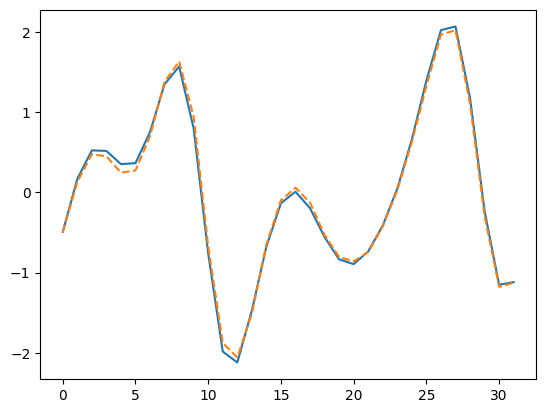

KeyboardInterrupt: 

In [8]:
# unroll, a priori model
# test one-step-in-future prediction
neuralop.eval()
fig, ax = plt.subplots()
for i in range(data_truncated[training_size:, :].size()[0]):
    uin = torch.reshape(data_truncated[i+training_size, :].to(torch.float32), (1, features.size()[1], 1))
    u_pred = neuralop(uin)
    mass = torch.mean(u_pred, dim=list(range(1, u_pred.dim()))).item()
    
    clear_output(wait=True)
    print(f'mass of estimate: {mass}, mass of solution: {torch.mean(data_truncated[i+dt+training_size, :])}')

    fig, ax = plt.subplots()
    ax.plot(data_truncated[i+dt+training_size, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()

    plt.pause(0.1)


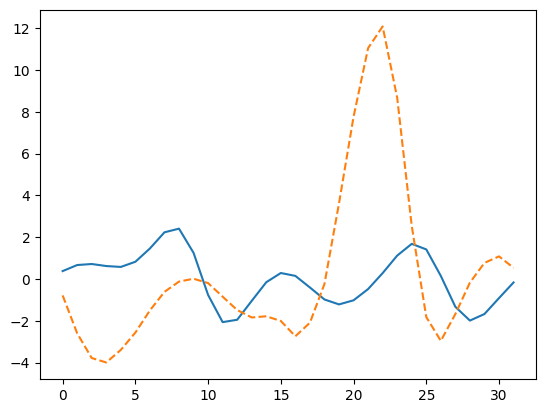

In [11]:
# unroll a posteriori. Systems diverge because of chaotic nature of PDE
# small scales tend to blow up! perhaps because they are heavily dissipated but still play a role
# i.e. their weights are very large
neuralop.eval()
uin = torch.reshape(data_truncated[training_size, :].to(torch.float32), (1, features.size()[1], 1))
#unroll_step = 2*dt

fig, ax = plt.subplots()
for i in range(0, data_truncated[training_size:, :].size(0)-dt, dt):
    clear_output(wait=True)
    fig, ax = plt.subplots()
    u_pred = neuralop(uin)
    ax.plot(data_truncated[i+dt+training_size, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()
    plt.pause(0.1)
    #if i%unroll_step == 0: 
    #    uin = torch.reshape(data_truncated[i+training_size, :].to(torch.float32), (1, features.size()[1], 1))
    #else: 
    uin = u_pred

In [10]:
# Apply model on higher prediction data
# first, load the data
with open('data/KuramotoSivashinsky/KS_N118.pkl', 'rb') as file:
    data_hr = pickle.load(file)
data_hr = torch.tensor(data_hr)
Nx_hr = data_hr.size()[1]

history = 1
dt = 1 # increasing this too much is bad
data_hr = data_hr[:history*(data_hr.size()[0]//history), :]

# dataloader
features = data_hr[training_size:-dt, :].to(torch.float32)
features = torch.reshape(features, (features.size()[0], features.size()[1], 1))

labels = data_hr[training_size+dt:, :].to(torch.float32)
labels = torch.reshape(labels, (labels.size()[0], labels.size()[1], 1))

testing_dataset_hr = TensorDataset(features, labels)
batch_size = 64
testing_dataloader_hr = DataLoader(testing_dataset_hr, batch_size=batch_size, shuffle=False)

In [11]:
# test on higher resolution data

# X: batch of tensors
# Nx: target resolution (smaller)
def fft_downsample(X, Nx):
    X = torch.fft.rfft(X, dim=1, norm="backward")
    return torch.fft.irfft(X[:, :Nx//2+1, :], dim=1, norm="backward")

def fft_upsample(X, Nx, Nx_hr):
    batch_size = X.size()[0]
    X = torch.fft.rfft(X, dim=1, norm="backward")
    X = torch.cat((X[:, :Nx//2+1, :], torch.zeros((batch_size, Nx_hr//2-Nx//2, 1))), 1)
    X = torch.fft.irfft(X, dim=1, norm="backward")
    return X

# downsample, predict, upsample
def test_hr(dataloader, model, loss_fn, Nx):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            Nx_hr = X.size()[1]
            batch_size = X.size()[0]

            # downsample
            X = fft_downsample(X, Nx)
            
            # predict
            pred = model(X).detach()

            # upsample
            pred = fft_upsample(pred, Nx, Nx_hr)

            # loss
            loss += loss_fn(pred, y).item()
            
    loss /= num_batches
    return loss

In [12]:
progress = test_hr(testing_dataloader_hr, neuralop, loss_fn, Nx)
print(progress)

0.5181225426495075


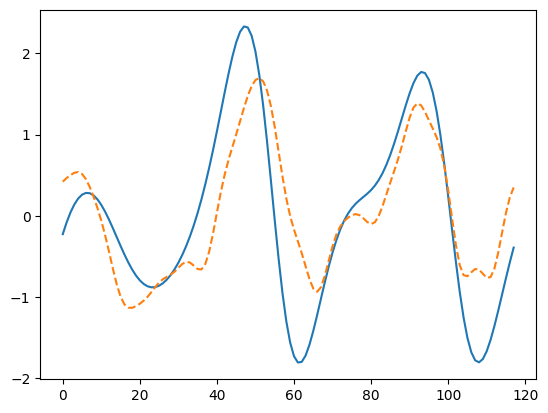

KeyboardInterrupt: 

In [110]:
# plot results
neuralop.eval()
for i in range(data_hr.size()[0]-dt):
    uin = torch.reshape(data_hr[i, :].to(torch.float32), (1, Nx_hr, 1))
    # downsample
    uin = torch.fft.rfft(uin, dim=1, norm="backward")
    uin = uin[:, :Nx//2+1]
    uin = torch.fft.irfft(uin, dim=1, norm="backward")

    # predict
    u_pred = neuralop(uin).detach()

    # upsample
    u_pred = torch.fft.rfft(u_pred, dim=1, norm="backward")
    u_pred = torch.cat((u_pred[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2, 1))), 1)
    u_pred = torch.fft.irfft(u_pred, dim=1, norm="backward")
    
    clear_output(wait=True)
    fig, ax = plt.subplots()
    
    ax.plot(data_hr[i+dt, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()
    plt.pause(0.1)

In [111]:
# test on a different timeseries (different initial condition)
with open('data/KuramotoSivashinsky/KS_N32_newInitial.pkl', 'rb') as file:
    data_ni = pickle.load(file)
data_ni = torch.tensor(data_ni)

history = 1
dt = 1 # increasing this too much is bad
data_ni = data_ni[:history*(data_ni.size()[0]//history), :]

# dataloader
features = data_ni[training_size:-dt, :].to(torch.float32)
features = torch.reshape(features, (features.size()[0], features.size()[1], 1))

labels = data_ni[training_size+dt:, :].to(torch.float32)
labels = torch.reshape(labels, (labels.size()[0], labels.size()[1], 1))

testing_dataset_ni = TensorDataset(features, labels)
batch_size = 64
testing_dataloader_ni = DataLoader(testing_dataset_ni, batch_size=batch_size, shuffle=False)

In [112]:
progress = test(testing_dataloader_ni, neuralop, loss_fn)
print(progress)

0.03571897652000189


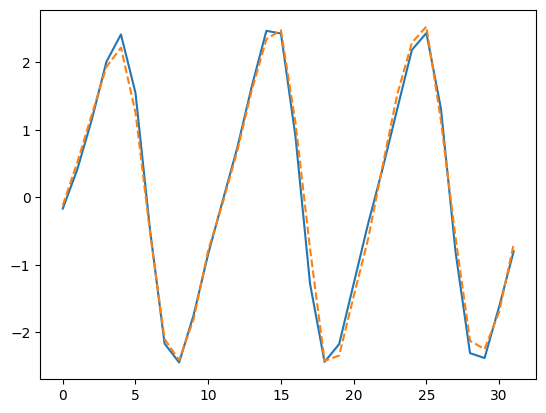

KeyboardInterrupt: 

In [113]:
# plots
neuralop.eval()
fig, ax = plt.subplots()
for i in range(data_ni.size()[0]):
    uin = torch.reshape(data_ni[i, :].to(torch.float32), (1, features.size()[1], 1))
    clear_output(wait=True)
    fig, ax = plt.subplots()
    u_pred = neuralop(uin)
    ax.plot(data_ni[i+dt, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()
    plt.pause(0.1)

# Remarks
## truncating high-frequencies stabilizes the a-posteriori rollout. But is this a-posteriori accurate? Or in other words, are they "plausible" solutions to the equations?

## enforcing conservation of mass is tricky: the nonlinear layer will always change the mass so we can't just enforce it using a special loss function

## what the nonlinear activation is applied to each fourier mode (if zeroth is zero anyway, it can be made to remain zero)

## in FNO formulation v_{t+1} = OneLayer(v_{t})? How can we learn the 'a posteriori' up to step T? i.e. predict the whole sequence up to step T and compare. Basically extract the output out of each layer and append to end


In [19]:
a = torch.rand((2, 3, 4))
b = torch.rand((2, 3, 4))
torch.cat((a, b), dim = -2).shape

torch.Size([2, 6, 4])